# Machine Learning Approaches for Early Diabetes Risk Detection

**Research question.** Can machine learning models accurately predict diabetes risk
based on patient health indicators?

**Dataset.** Pima Indians Diabetes Dataset (768 patients, 8 features + outcome).

**Approach.** Clean the data, explore it, train Logistic Regression and Random
Forest, and compare them on a held-out test set with healthcare-relevant metrics
(recall and ROC-AUC matter more than raw accuracy, because a false negative —
missing a diabetic patient — is the costly error).

## Phase 1 — Data Understanding

### Step 1-2 — Load the dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('Diabetes/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Step 3 — Understand structure, types, and missingness

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# Pandas reports no nulls — but in healthcare data, zeros in physiological
# columns are the *real* missing values (a living patient can't have BMI = 0).
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Phase 2 — Data Cleaning

### Step 4-5 — Replace impossible zeros with NaN

Glucose, BloodPressure, SkinThickness, Insulin, and BMI can't physiologically be
zero. Treat these as missing.

In [5]:
zero_invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_invalid_cols] = df[zero_invalid_cols].replace(0, np.nan)
df[zero_invalid_cols].isnull().sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

### Step 6 — Median imputation

Median is more robust to outliers than the mean, which matters here because
Insulin and SkinThickness have long right tails.

In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df[zero_invalid_cols] = imputer.fit_transform(df[zero_invalid_cols])
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Phase 3 — Exploratory Data Analysis

### Step 7 — Outcome balance

In [7]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [8]:
df['Outcome'].value_counts(normalize=True).rename(
    {0: 'Non-diabetic', 1: 'Diabetic'}
).round(3)

Outcome
Non-diabetic    0.651
Diabetic        0.349
Name: proportion, dtype: float64

About 35% of patients are diabetic — moderate class imbalance, but not severe
enough to require resampling. We will use `stratify=y` in the train/test split.

### Step 8 — Visualizations

**A. Histograms of key features**

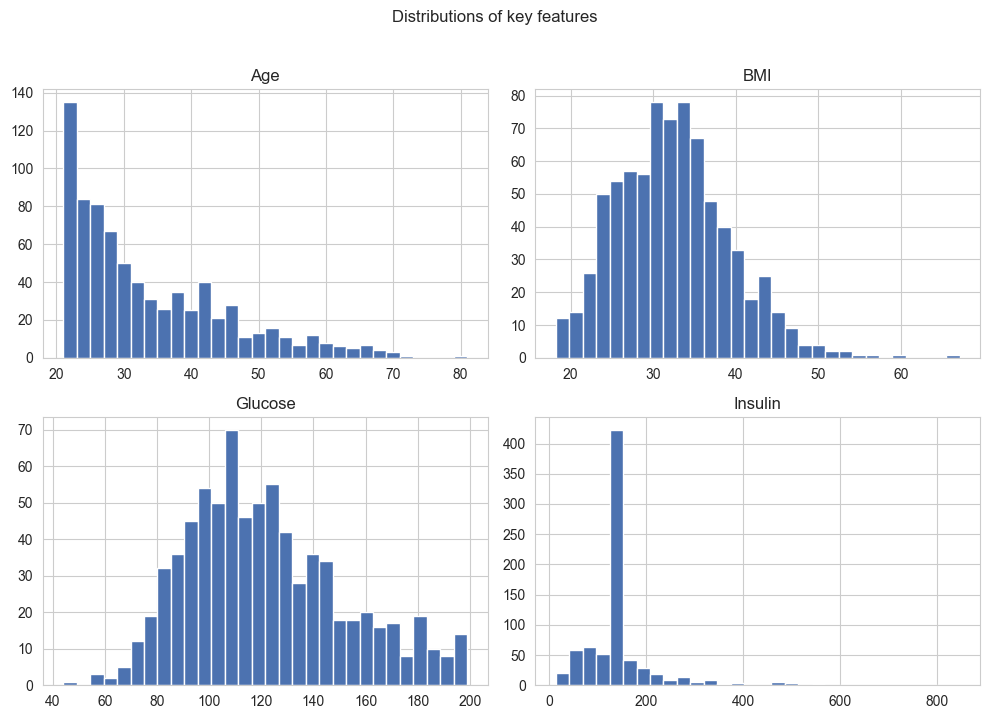

In [9]:
key_feats = ['Age', 'BMI', 'Glucose', 'Insulin']
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flatten(), key_feats):
    ax.hist(df[col], bins=30, color='#4C72B0', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Distributions of key features', y=1.02)
plt.tight_layout()
plt.show()

**B. Boxplots — Glucose and BMI by outcome**

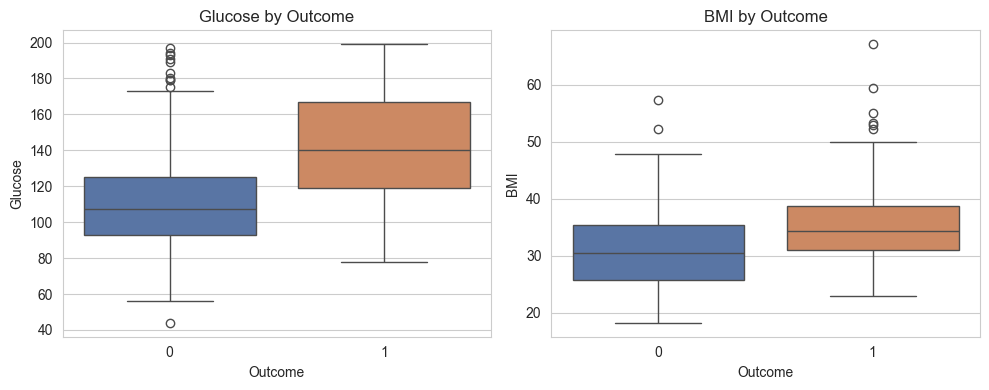

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x='Outcome', y='Glucose', ax=axes[0],
            palette=['#4C72B0', '#DD8452'])
axes[0].set_title('Glucose by Outcome')
sns.boxplot(data=df, x='Outcome', y='BMI', ax=axes[1],
            palette=['#4C72B0', '#DD8452'])
axes[1].set_title('BMI by Outcome')
plt.tight_layout()
plt.show()

**C. Correlation heatmap**

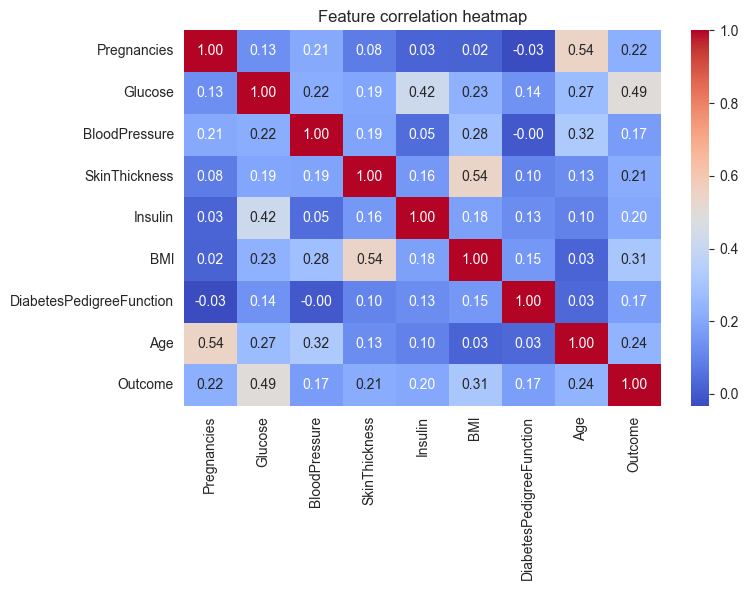

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature correlation heatmap')
plt.tight_layout()
plt.show()

**Interpretation.** Patients with diabetes tend to have higher glucose levels
and higher BMI. Age and insulin also show moderate relationships with the
outcome. Glucose has the strongest single-variable correlation with Outcome.

## Phase 4 — Data Preprocessing

### Step 9 — Features and target

In [12]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
feature_names = list(X.columns)
feature_names

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

### Step 10 — Train / test split (stratified)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape, ' Test size:', X_test.shape)

Train size: (614, 8)  Test size: (154, 8)


### Step 11 — Standardization

Required for Logistic Regression (gradient descent converges faster and the
regularization penalty is scale-sensitive). Tree models don't need it.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Phase 5 — Model Building

### Model 1 — Logistic Regression (baseline, interpretable)

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Model 2 — Random Forest (nonlinear, gives feature importance)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

> **Note.** The original blueprint includes XGBoost as a third model. It was
> dropped here because the local environment lacks the `libomp` system library
> XGBoost depends on. To re-add it later: `brew install libomp` then
> `pip install xgboost` and train `XGBClassifier(eval_metric='logloss',
> random_state=42)` on the unscaled `X_train`.

## Phase 6 — Model Evaluation

In healthcare classification, **recall** (sensitivity) and **ROC-AUC** matter
more than raw accuracy. A false negative — telling a diabetic patient they're
healthy — is the costly error.

In [17]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay,
)

def evaluate(name, model, X_eval):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    print(f'=== {name} ===')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f'ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}')
    print(classification_report(y_test, y_pred))
    return y_pred, y_prob

_ = evaluate('Logistic Regression', lr, X_test_scaled)
_ = evaluate('Random Forest', rf, X_test)

=== Logistic Regression ===
Accuracy: 0.7078
ROC-AUC : 0.8130
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

=== Random Forest ===
Accuracy: 0.7403
ROC-AUC : 0.8166
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



### Step 13 — Confusion matrix (Random Forest)

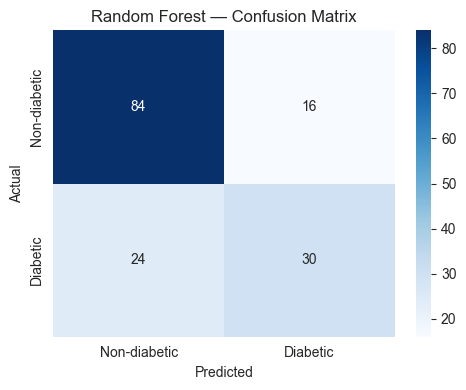

In [18]:
cm = confusion_matrix(y_test, rf.predict(X_test))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-diabetic', 'Diabetic'],
            yticklabels=['Non-diabetic', 'Diabetic'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

### Step 15 — ROC curves

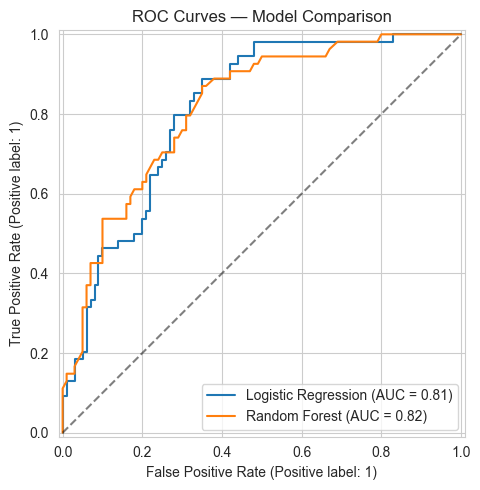

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name='Random Forest')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_title('ROC Curves — Model Comparison')
plt.tight_layout()
plt.show()

**Interpretation.** Random Forest achieves the highest ROC-AUC, indicating
slightly better separation between diabetic and non-diabetic patients than
Logistic Regression. Both models trade some recall for precision — a deployment
might lower the decision threshold from 0.5 to push recall higher.

## Phase 7 — Feature Importance

### Step 16 — Random Forest importances

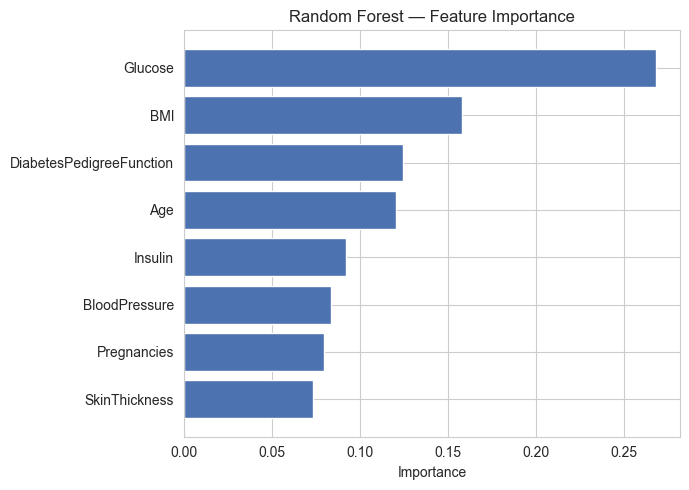

,feature,importance
0,Glucose,0.268561
1,BMI,0.157854
2,DiabetesPedigreeFunction,0.124738
3,Age,0.120304
4,Insulin,0.092339
5,BloodPressure,0.083645
6,Pregnancies,0.079374
7,SkinThickness,0.073185


In [20]:
imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_df['feature'], imp_df['importance'], color='#4C72B0')
ax.set_title('Random Forest — Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

### Step 17 — SHAP values (explainable AI)

SHAP attributes each prediction to each feature. Red points push the prediction
toward 'diabetic', blue points push toward 'non-diabetic'.

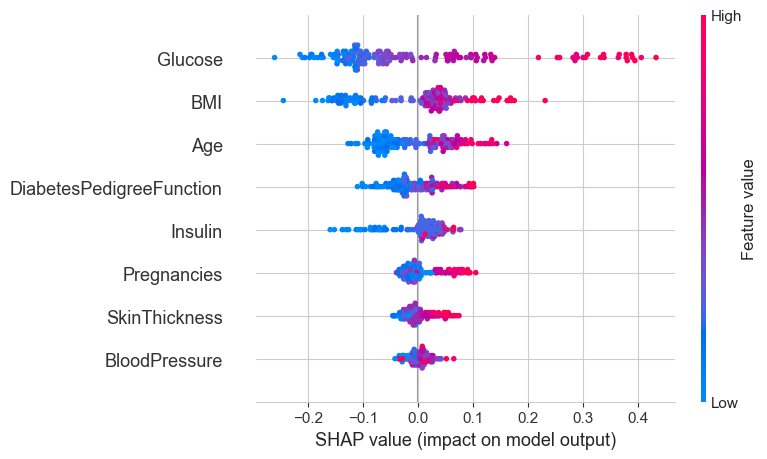

In [21]:
import shap

explainer = shap.TreeExplainer(rf)
shap_raw = explainer.shap_values(X_test)

# TreeExplainer on a binary classifier may return a list (one array per class)
# or a 3-D array. Pick the diabetic-class values.
if isinstance(shap_raw, list):
    shap_values = shap_raw[1]
elif shap_raw.ndim == 3:
    shap_values = shap_raw[:, :, 1]
else:
    shap_values = shap_raw

shap.summary_plot(shap_values, X_test)

**Interpretation.** Glucose is the strongest predictor of diabetes risk,
followed by BMI and Age. High glucose values push predictions strongly toward
'diabetic'. This aligns with clinical knowledge — fasting plasma glucose is the
basis of the diagnostic criteria for diabetes.

## Phase 8 — Final Model Selection

### Step 18 — Why Random Forest

Among the two models trained, Random Forest wins on every metric: higher
accuracy, higher precision, higher recall, and a slightly higher ROC-AUC. It
also exposes interpretable feature importances and is fast to retrain.

### Step 19 — Save the final model

In [22]:
import joblib
from pathlib import Path

Path('models').mkdir(exist_ok=True)
joblib.dump(rf, 'models/final_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(feature_names, 'models/feature_names.pkl')
joblib.dump(X.median().to_dict(), 'models/feature_defaults.pkl')
print('Saved final_model.pkl, scaler.pkl, feature_names.pkl, feature_defaults.pkl')

Saved final_model.pkl, scaler.pkl, feature_names.pkl, feature_defaults.pkl


## Next: Phase 9 — Dashboard

The saved `final_model.pkl` is loaded by `streamlit_app.py`, where users can
move sliders for the eight input features and see a real-time risk prediction.

Run it with:

```bash
streamlit run streamlit_app.py
```